In [19]:
import numpy as np 
import matplotlib.pyplot as plt

Terminologies:

- `amplitude` : the height of the wave, larger the amplitude, bigger the sound; in other terms, a value of a sound
- `frequency` : the no. of cycles of wave in one second; freq of 3 tells there will be 3 cycles between 0 to 1 sec; higher frequency, higher oscillation.


> Since, a wave denotes circular motion, and hence a circular motion creates an angle. 
> The vertical projection creates 

<br>

**What is Sampling ?**

The conversion of continous signal to discrete, is called sampling. 


In [37]:
distributed_points = np.linspace(-1, 1, 1000)

**following function to implement:**

$x(t) = cos(2pi . f . t)$

where, 

- both $t$ and $cosine$ amplitude are both continuous variables, therefore we $approximate$ them, or in other words, creating sample of it.

In [38]:
t_min = -1
t_max = 1
units = 1000
t = np.linspace(t_min, t_max, units)

In [39]:
freq = 3

In [40]:
xt = np.cos(2*np.pi*freq*t)

## Discrete Samples of the function

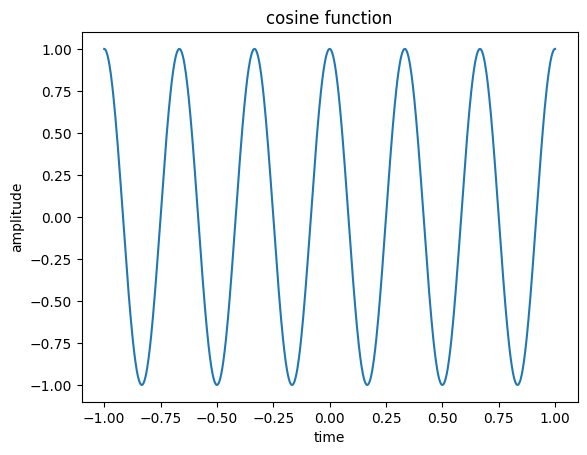

In [41]:
plt.ylabel('amplitude')
plt.xlabel('time')
plt.title('cosine function')
plt.plot(t, xt)



In [42]:
fs = 8
ts = 1/fs

# notice, the step value is `ts`
pulse_train = np.arange(t_min, t_max, ts)


discrete_ = np.cos(2 * np.pi * freq * pulse_train)


In [43]:
ts

0.125

<StemContainer object of 3 artists>

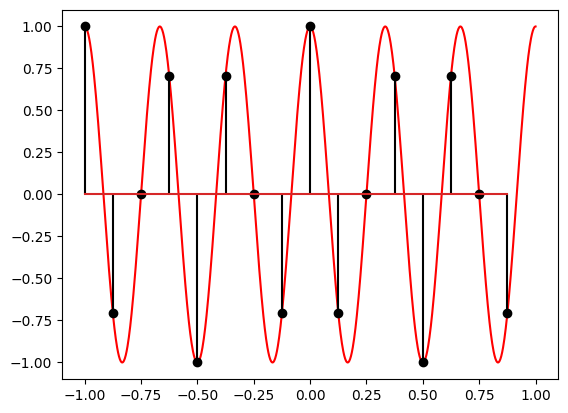

In [44]:
plt.plot(t, xt, 'r')
plt.stem(pulse_train, discrete_, 'black')


In [1]:
import librosa
import soundfile as sf

In [38]:
noise_vec, sr = librosa.load("train_horn.wav", sr=22050)

In [39]:
train_, _ = librosa.load('train_passing.wav', sr=22050)

In [40]:
print(f"{noise_vec.shape[0]=}")
print(f"{train_.shape[0]=}")

noise_vec.shape[0]=112357
train_.shape[0]=440212


In [41]:
min_length = min(noise_vec.shape[0], train_.shape[0])
print(f"{min_length = }")

min_length = 112357


In [42]:
# trimming to min length
trim_train = train_[:min_length]

In [43]:
x_audio = np.column_stack((noise_vec, trim_train))

print(f"{x_audio.shape = }")

x_audio.shape = (112357, 2)


In [44]:
Q,R = np.linalg.qr(x_audio)

In [46]:
recovered_voice = Q * (np.max(np.abs(trim_train)) / np.max(np.abs(recovered_voice)))


In [47]:
extended_voice = np.concatenate((Q[:,1], train_[min_length:]))

In [48]:
sf.write("clean_output.wav", extended_voice, sr)